In [ ]:
import pandas as pd

df = pd.read_csv('/content/cleaned_reviews.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSentiment Distribution:")
print(df['sentiments'].value_counts())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (10827, 4)

Columns:
['sentiments', 'cleaned_review', 'cleaned_review_length', 'review_score']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10827 entries, 0 to 10826
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sentiments             10827 non-null  object 
 1   cleaned_review         10824 non-null  object 
 2   cleaned_review_length  10826 non-null  float64
 3   review_score           10826 non-null  float64
dtypes: float64(2), object(2)
memory usage: 338.5+ KB

Missing Values:
sentiments               0
cleaned_review           3
cleaned_review_length    1
review_score             1
dtype: int64

Duplicate Rows: 992

Sentiment Distribution:
sentiments
positive    5127
neutral     4444
negative    1256
Name: count, dtype: int64

First 5 Rows:


,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19.0,5.0
1,neutral,i ve learned this lesson again open the packag...,88.0,1.0
2,neutral,it is so slow and lags find better option,9.0,2.0
3,neutral,roller ball stopped working within months of m...,12.0,1.0
4,neutral,i like the color and size but it few days out ...,21.0,1.0


In [ ]:
# ==========================================
# STEP 2 — DATA CLEANING & VALIDATION
# ==========================================

import pandas as pd
import numpy as np

# Work on a copy
df_clean = df.copy()

print("BEFORE CLEANING")
print("=" * 45)
print("Rows:", len(df_clean))
print("Missing values:")
print(df_clean.isnull().sum())
print("Duplicate rows:", df_clean.duplicated().sum())


# 1. Remove rows where review text is missing
df_clean = df_clean.dropna(subset=['cleaned_review'])

# 2. Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# 3. Clean review text
df_clean['cleaned_review'] = (
    df_clean['cleaned_review']
    .astype(str)
    .str.strip()
)

# Remove any empty reviews
df_clean = df_clean[df_clean['cleaned_review'] != '']

# 4. Recalculate review length from actual text
df_clean['cleaned_review_length'] = (
    df_clean['cleaned_review']
    .str.split()
    .str.len()
)

# 5. Make sure review score is numeric
df_clean['review_score'] = pd.to_numeric(
    df_clean['review_score'],
    errors='coerce'
)

# 6. Remove rows where sentiment/review score is missing
df_clean = df_clean.dropna(
    subset=['sentiments', 'review_score']
)

# Reset index
df_clean = df_clean.reset_index(drop=True)


# ==========================================
# CLEANING RESULTS
# ==========================================

print("\nAFTER CLEANING")
print("=" * 45)

print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:", df_clean.duplicated().sum())

print("\nSentiment distribution:")
print(df_clean['sentiments'].value_counts())

print("\nReview score distribution:")
print(df_clean['review_score'].value_counts().sort_index())

print("\nClean dataset preview:")
display(df_clean.head())

BEFORE CLEANING
Rows: 10827
Missing values:
sentiments               0
cleaned_review           3
cleaned_review_length    1
review_score             1
dtype: int64
Duplicate rows: 992

AFTER CLEANING
Rows: 9829
Columns: 4

Missing values:
sentiments               0
cleaned_review           0
cleaned_review_length    0
review_score             0
dtype: int64

Duplicate rows: 28

Sentiment distribution:
sentiments
positive    4642
neutral     4035
negative    1152
Name: count, dtype: int64

Review score distribution:
review_score
1.0    2956
2.0    1040
3.0     816
4.0     944
5.0    4073
Name: count, dtype: int64

Clean dataset preview:


,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0


CLEANED DATASET CHECK
Rows: 9829

Sentiment counts:
sentiments
positive    4642
neutral     4035
negative    1152
Name: count, dtype: int64

Missing values:
sentiments               0
cleaned_review           0
cleaned_review_length    0
review_score             0
dtype: int64


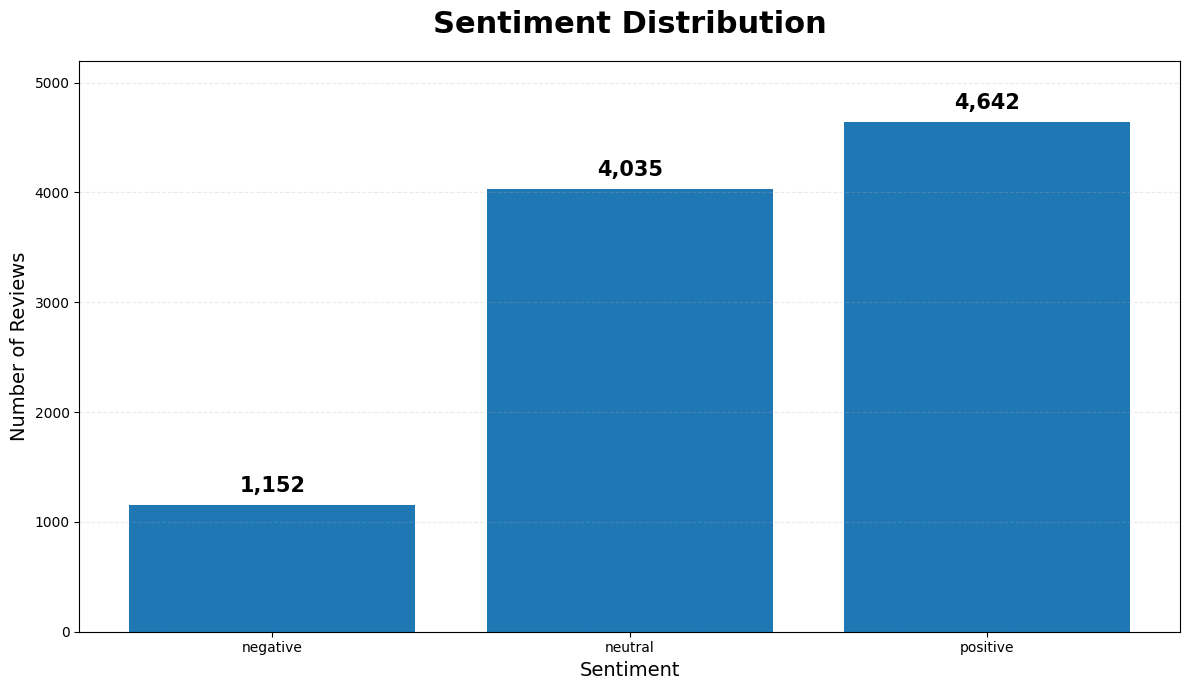

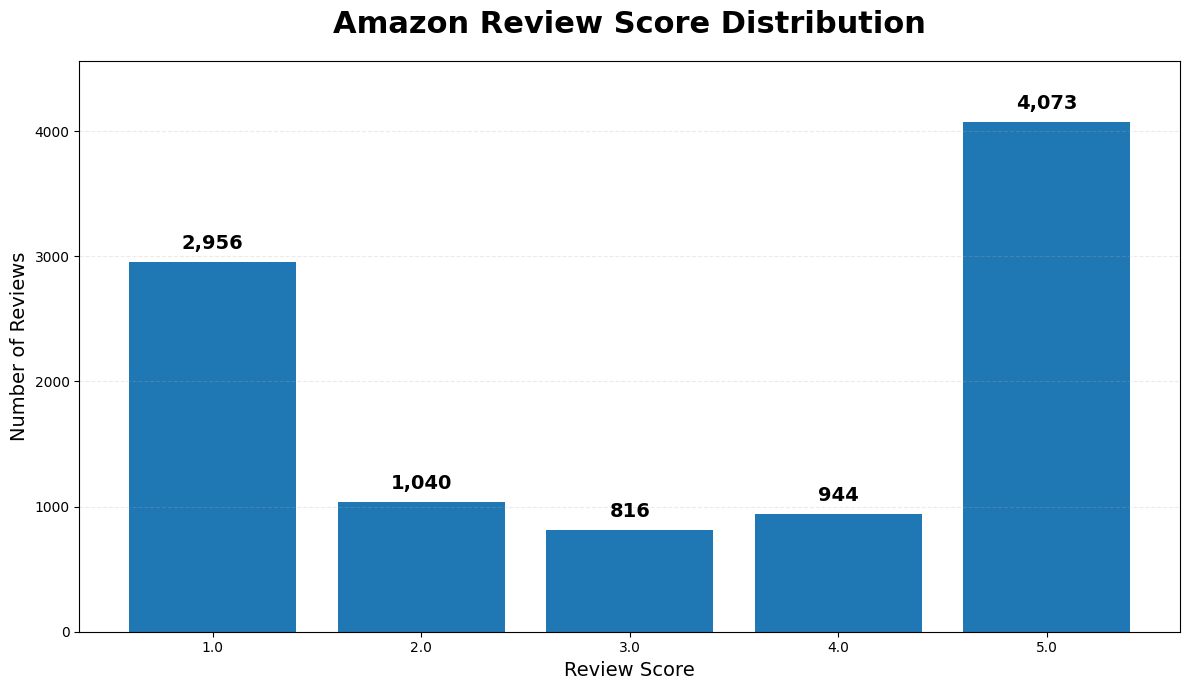

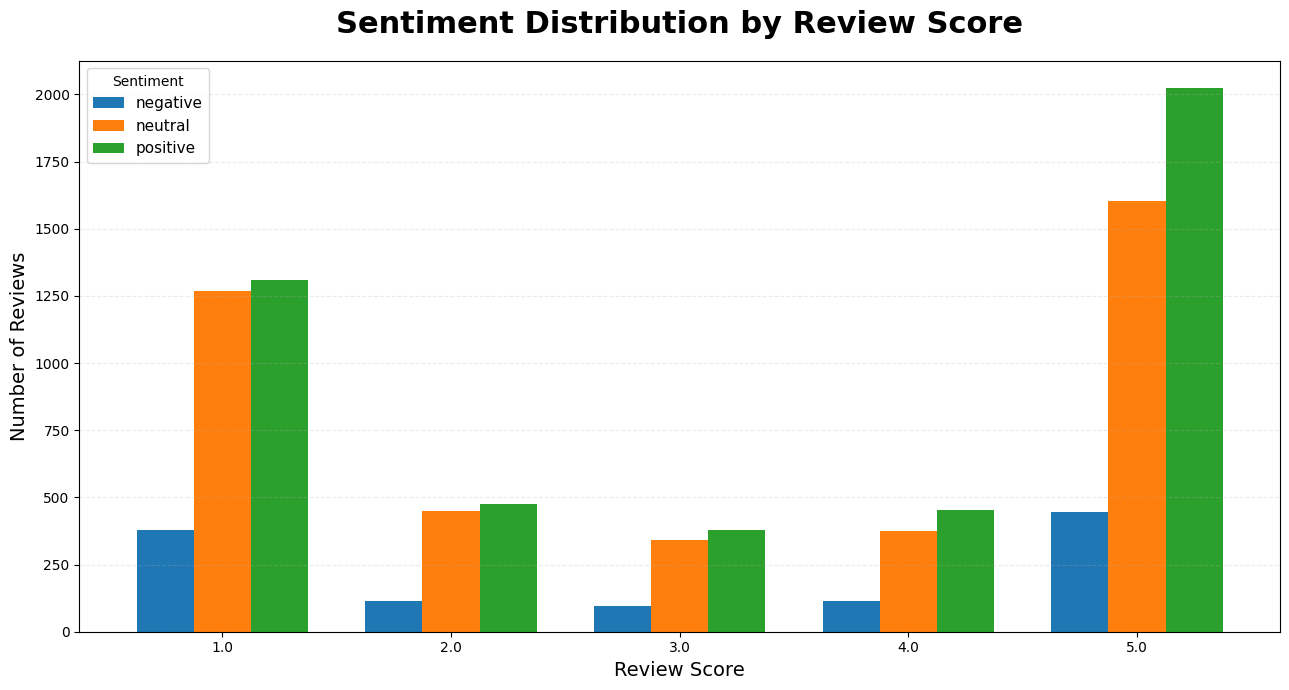

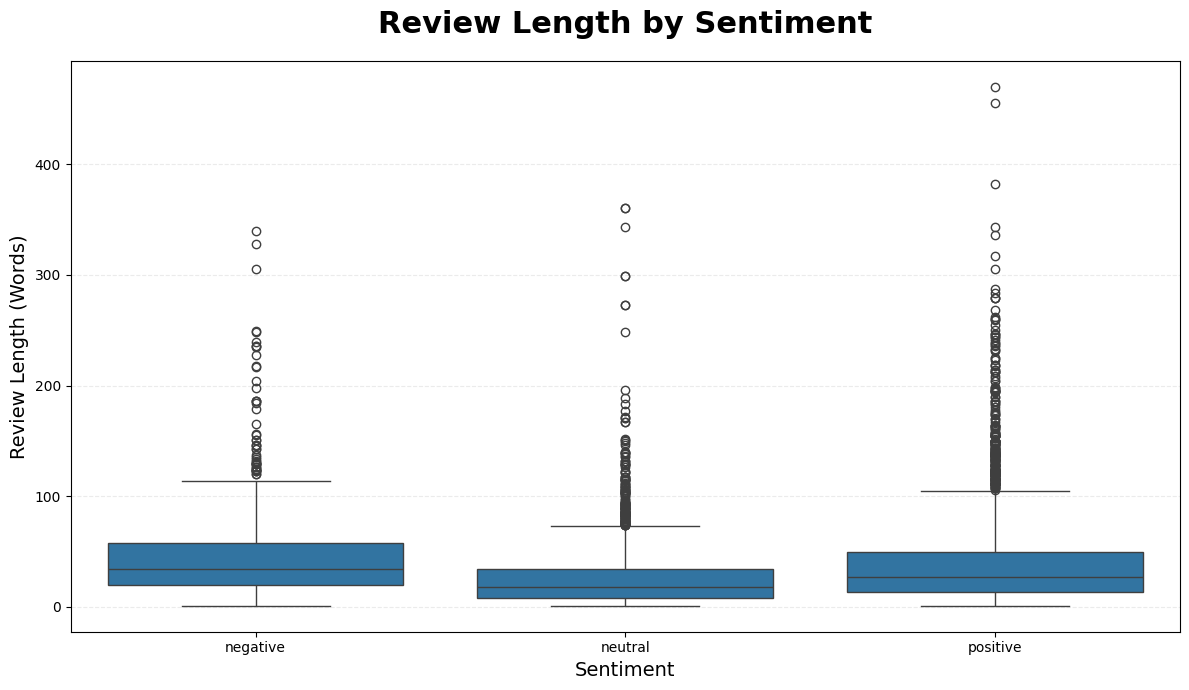

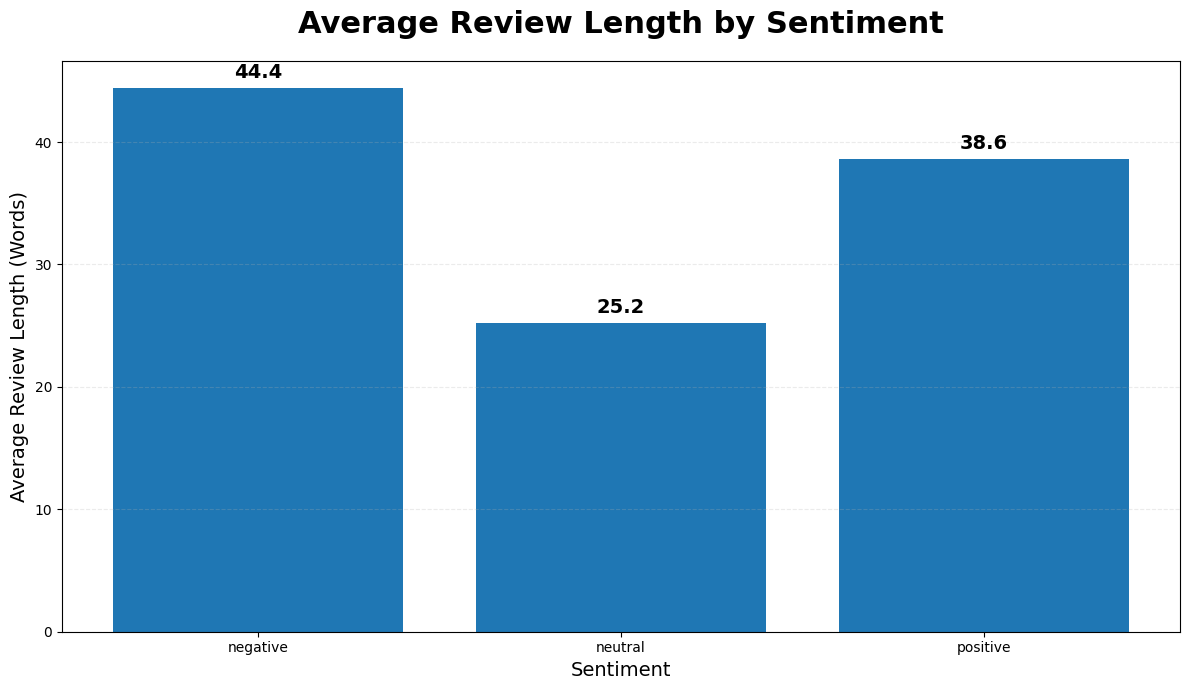

In [ ]:
# ============================================================
# STEP 3 — SENTIMENT ANALYSIS VISUALIZATIONS
# USING ONLY THE CLEANED DATASET
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# IMPORTANT:
# Yahan apne CLEANED dataframe ka naam likho.
# Agar tumhara cleaned dataframe "df_clean" hai:
# cleaned_df = df_clean.copy()
#
# Agar cleaning ke baad dataframe ka naam "df" hai:
# cleaned_df = df.copy()
# ------------------------------------------------------------

cleaned_df = df_clean.copy()   # <-- apne cleaned dataframe ka naam yahan rakho


# ============================================================
# CHECK CLEANED DATA
# ============================================================

print("=" * 60)
print("CLEANED DATASET CHECK")
print("=" * 60)

print("Rows:", len(cleaned_df))
print("\nSentiment counts:")
print(cleaned_df["sentiments"].value_counts())

print("\nMissing values:")
print(cleaned_df[[
    "sentiments",
    "cleaned_review",
    "cleaned_review_length",
    "review_score"
]].isnull().sum())


# ============================================================
# 1. SENTIMENT DISTRIBUTION
# ============================================================

sentiment_order = ["negative", "neutral", "positive"]

sentiment_counts = (
    cleaned_df["sentiments"]
    .value_counts()
    .reindex(sentiment_order)
)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title(
    "Sentiment Distribution",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.xlabel("Sentiment", fontsize=14)
plt.ylabel("Number of Reviews", fontsize=14)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Values on bars
for bar, value in zip(bars, sentiment_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=15,
        fontweight="bold"
    )

plt.ylim(0, sentiment_counts.max() * 1.12)

plt.tight_layout()
plt.show()


# ============================================================
# 2. REVIEW SCORE DISTRIBUTION
# ============================================================

score_counts = (
    cleaned_df["review_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.title(
    "Amazon Review Score Distribution",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.xlabel("Review Score", fontsize=14)
plt.ylabel("Number of Reviews", fontsize=14)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar, value in zip(bars, score_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 70,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

plt.ylim(0, score_counts.max() * 1.12)

plt.tight_layout()
plt.show()


# ============================================================
# 3. SENTIMENT vs REVIEW SCORE
# ============================================================

sentiment_score = pd.crosstab(
    cleaned_df["review_score"],
    cleaned_df["sentiments"]
)

sentiment_score = sentiment_score[
    ["negative", "neutral", "positive"]
]

ax = sentiment_score.plot(
    kind="bar",
    figsize=(13, 7),
    width=0.75
)

plt.title(
    "Sentiment Distribution by Review Score",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.xlabel("Review Score", fontsize=14)
plt.ylabel("Number of Reviews", fontsize=14)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.legend(
    title="Sentiment",
    fontsize=11
)

plt.tight_layout()
plt.show()


# ============================================================
# 4. REVIEW LENGTH BY SENTIMENT
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=cleaned_df,
    x="sentiments",
    y="cleaned_review_length",
    order=sentiment_order
)

plt.title(
    "Review Length by Sentiment",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.xlabel("Sentiment", fontsize=14)
plt.ylabel("Review Length (Words)", fontsize=14)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. AVERAGE REVIEW LENGTH BY SENTIMENT
# ============================================================

avg_length = (
    cleaned_df
    .groupby("sentiments")["cleaned_review_length"]
    .mean()
    .reindex(sentiment_order)
)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    avg_length.index,
    avg_length.values
)

plt.title(
    "Average Review Length by Sentiment",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.xlabel("Sentiment", fontsize=14)
plt.ylabel("Average Review Length (Words)", fontsize=14)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar, value in zip(bars, avg_length.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [ ]:
!pip install NRCLex -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00


Reviews available: 9829
NRC Lexicon downloaded successfully.
Lexicon rows: 13901

NLP EMOTION ANALYSIS RESULTS
joy         7057
anger       4760
sadness     4535
fear        3172
surprise    4344
disgust     2232
dtype: int64


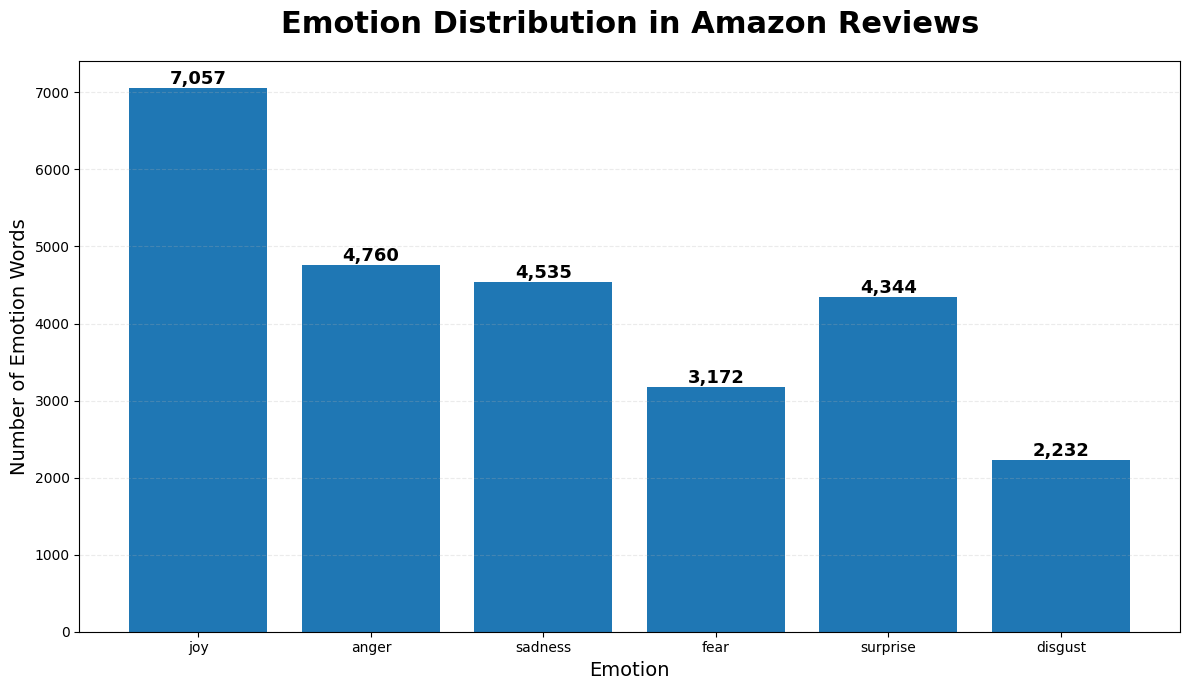

In [ ]:
# ============================================================
# STEP 4 — NLP EMOTION ANALYSIS
# NRC EMOTION LEXICON
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import zipfile
import io
import os
import re

# ------------------------------------------------------------
# 1. USE CLEANED DATASET
# ------------------------------------------------------------

emotion_df = cleaned_df.copy()

emotion_df["cleaned_review"] = (
    emotion_df["cleaned_review"]
    .fillna("")
    .astype(str)
)

print("Reviews available:", len(emotion_df))


# ------------------------------------------------------------
# 2. DOWNLOAD NRC EMOTION LEXICON
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/Franck-Dernoncourt/NRC_Emotion_Lexicon/master/NRC-emotion-lexicon-wordlevel-alphabetized-v0.92.txt"

response = requests.get(url)

if response.status_code != 200:
    raise Exception("NRC Lexicon download failed.")

print("NRC Lexicon downloaded successfully.")


# ------------------------------------------------------------
# 3. READ NRC LEXICON
# ------------------------------------------------------------

lexicon = pd.read_csv(
    io.StringIO(response.text),
    sep="\t",
    names=["word", "emotion", "association"],
    skiprows=45
)

# Keep only words associated with an emotion
lexicon = lexicon[lexicon["association"] == 1]

print("Lexicon rows:", len(lexicon))


# ------------------------------------------------------------
# 4. CREATE WORD → EMOTION DICTIONARY
# ------------------------------------------------------------

emotion_words = {}

for _, row in lexicon.iterrows():

    word = row["word"]
    emotion = row["emotion"]

    if word not in emotion_words:
        emotion_words[word] = []

    emotion_words[word].append(emotion)


# ------------------------------------------------------------
# 5. EMOTIONS WE WANT
# ------------------------------------------------------------

emotion_list = [
    "joy",
    "anger",
    "sadness",
    "fear",
    "surprise",
    "disgust"
]


# ------------------------------------------------------------
# 6. FUNCTION TO DETECT EMOTIONS
# ------------------------------------------------------------

def detect_emotions(text):

    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

    scores = {
        emotion: 0
        for emotion in emotion_list
    }

    for word in words:

        if word in emotion_words:

            for emotion in emotion_words[word]:

                if emotion in scores:
                    scores[emotion] += 1

    return scores


# ------------------------------------------------------------
# 7. APPLY EMOTION ANALYSIS
# ------------------------------------------------------------

emotion_df["emotion_scores"] = (
    emotion_df["cleaned_review"]
    .apply(detect_emotions)
)


# ------------------------------------------------------------
# 8. CALCULATE TOTAL EMOTIONS
# ------------------------------------------------------------

emotion_counts = {}

for emotion in emotion_list:

    emotion_counts[emotion] = (
        emotion_df["emotion_scores"]
        .apply(lambda x: x[emotion])
        .sum()
    )

emotion_counts = pd.Series(emotion_counts)


# ------------------------------------------------------------
# 9. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NLP EMOTION ANALYSIS RESULTS")
print("=" * 60)

print(emotion_counts)


# ------------------------------------------------------------
# 10. EMOTION DISTRIBUTION CHART
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

bars = plt.bar(
    emotion_counts.index,
    emotion_counts.values
)

plt.title(
    "Emotion Distribution in Amazon Reviews",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Emotion",
    fontsize=14
)

plt.ylabel(
    "Number of Emotion Words",
    fontsize=14
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar, value in zip(
    bars,
    emotion_counts.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# EMOTIONS BY SENTIMENT
# ============================================================

emotion_by_sentiment = {}

for sentiment in ["negative", "neutral", "positive"]:

    subset = emotion_df[
        emotion_df["sentiments"] == sentiment
    ]

    emotion_by_sentiment[sentiment] = {}

    for emotion in emotion_list:

        emotion_by_sentiment[sentiment][emotion] = (
            subset["emotion_scores"]
            .apply(lambda x: x[emotion])
            .sum()
        )


emotion_by_sentiment = pd.DataFrame(
    emotion_by_sentiment
).T


print("=" * 60)
print("EMOTIONS BY SENTIMENT")
print("=" * 60)

display(emotion_by_sentiment)

EMOTIONS BY SENTIMENT


,joy,anger,sadness,fear,surprise,disgust
negative,626,1195,1236,877,638,786
neutral,1327,1386,1494,1110,1193,734
positive,5104,2179,1805,1185,2513,712


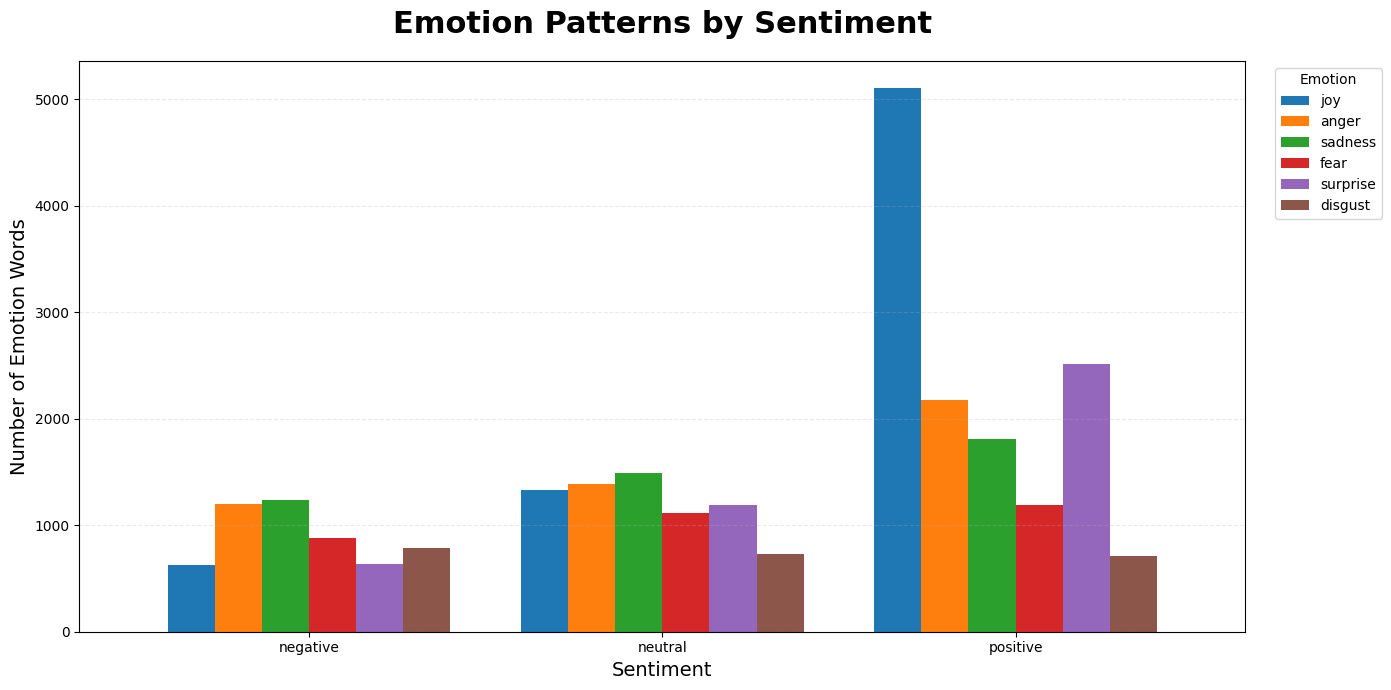

In [ ]:
# ============================================================
# EMOTION PATTERNS BY SENTIMENT
# ============================================================

ax = emotion_by_sentiment.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

plt.title(
    "Emotion Patterns by Sentiment",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Sentiment",
    fontsize=14
)

plt.ylabel(
    "Number of Emotion Words",
    fontsize=14
)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.legend(
    title="Emotion",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

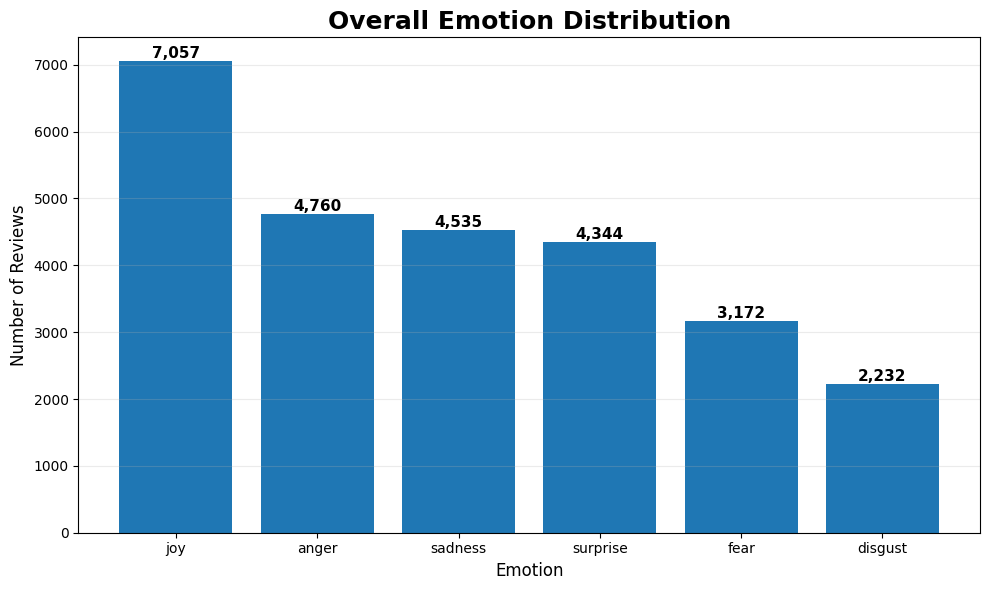

<Figure size 1200x700 with 0 Axes>

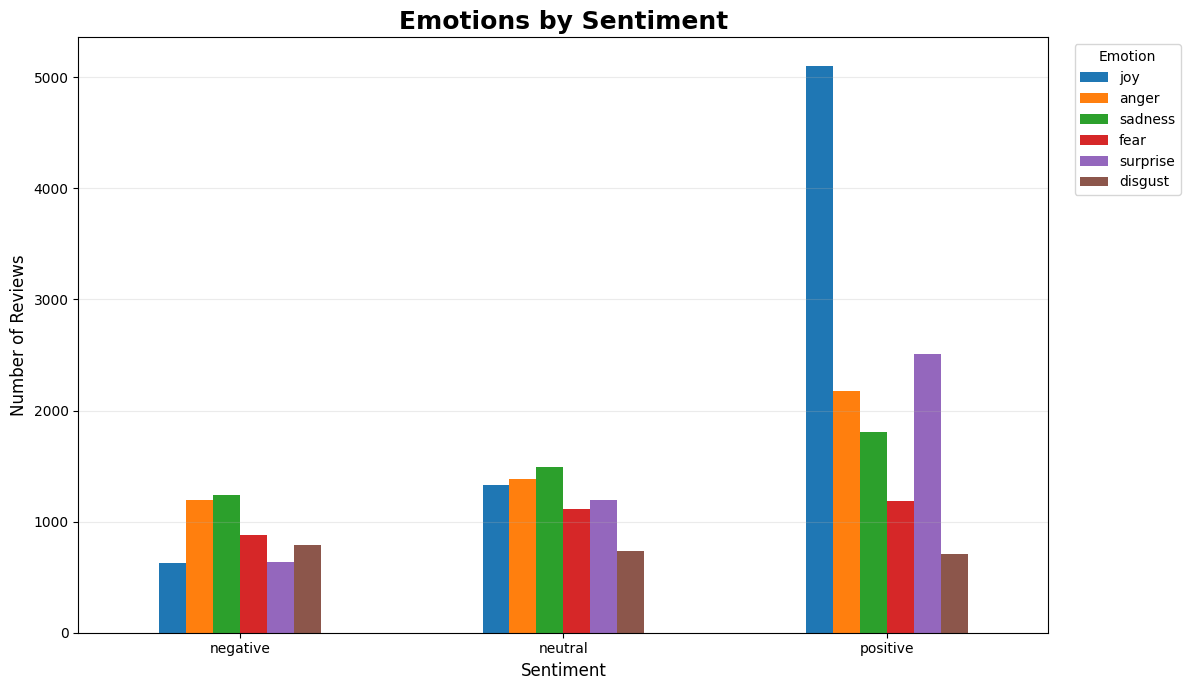

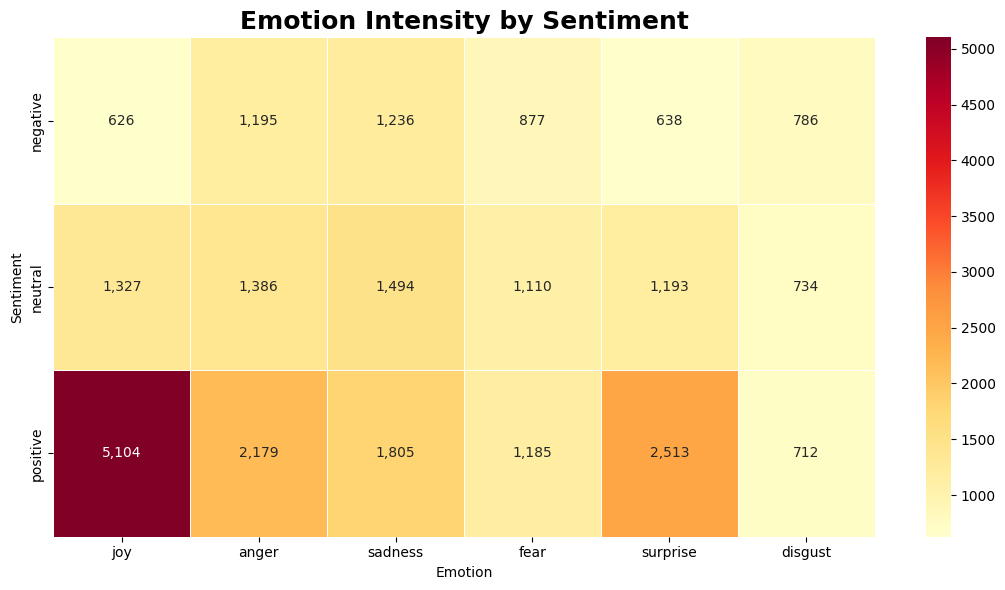

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 4 — EMOTION ANALYSIS VISUALIZATION
# ==========================================

emotion_cols = [
    'joy',
    'anger',
    'sadness',
    'fear',
    'surprise',
    'disgust'
]

# ------------------------------------------
# 1. Overall Emotion Distribution
# ------------------------------------------

emotion_totals = emotion_by_sentiment[emotion_cols].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    emotion_totals.index,
    emotion_totals.values
)

plt.title(
    'Overall Emotion Distribution',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

plt.grid(axis='y', alpha=0.25)

for bar, value in zip(bars, emotion_totals.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:,}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# ------------------------------------------
# 2. Emotion by Sentiment — Grouped Bar
# ------------------------------------------

plt.figure(figsize=(12, 7))

emotion_by_sentiment[emotion_cols].plot(
    kind='bar',
    figsize=(12, 7)
)

plt.title(
    'Emotions by Sentiment',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.25)

plt.legend(
    title='Emotion',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


# ------------------------------------------
# 3. Emotion Heatmap
# ------------------------------------------

plt.figure(figsize=(11, 6))

sns.heatmap(
    emotion_by_sentiment[emotion_cols],
    annot=True,
    fmt=',',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title(
    'Emotion Intensity by Sentiment',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Emotion')
plt.ylabel('Sentiment')

plt.tight_layout()
plt.show()

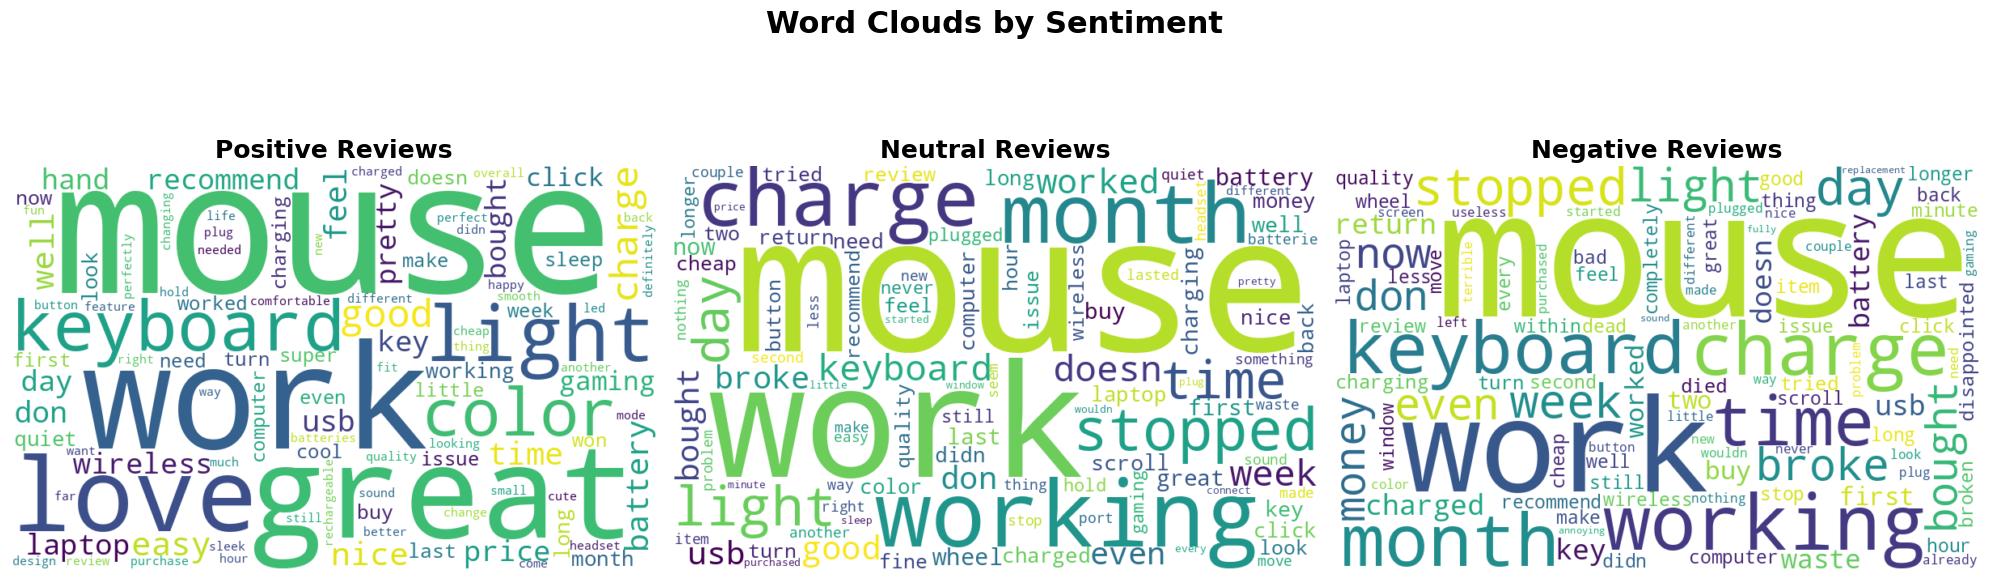


TOP 20 WORDS — POSITIVE REVIEWS
mouse                     3,575
great                     1,889
love                      1,438
like                      1,144
keyboard                  1,144
works                     1,047
good                      935
work                      917
lights                    878
when                      871
charge                    823
easy                      686
well                      667
nice                      664
battery                   625
light                     611
only                      584
colors                    566
off                       543
don                       535

TOP 20 WORDS — NEUTRAL REVIEWS
mouse                     2,045
work                      909
working                   858
after                     837
stopped                   620
charge                    599
only                      532
when                      530
like                      473
months                    450
doesn                

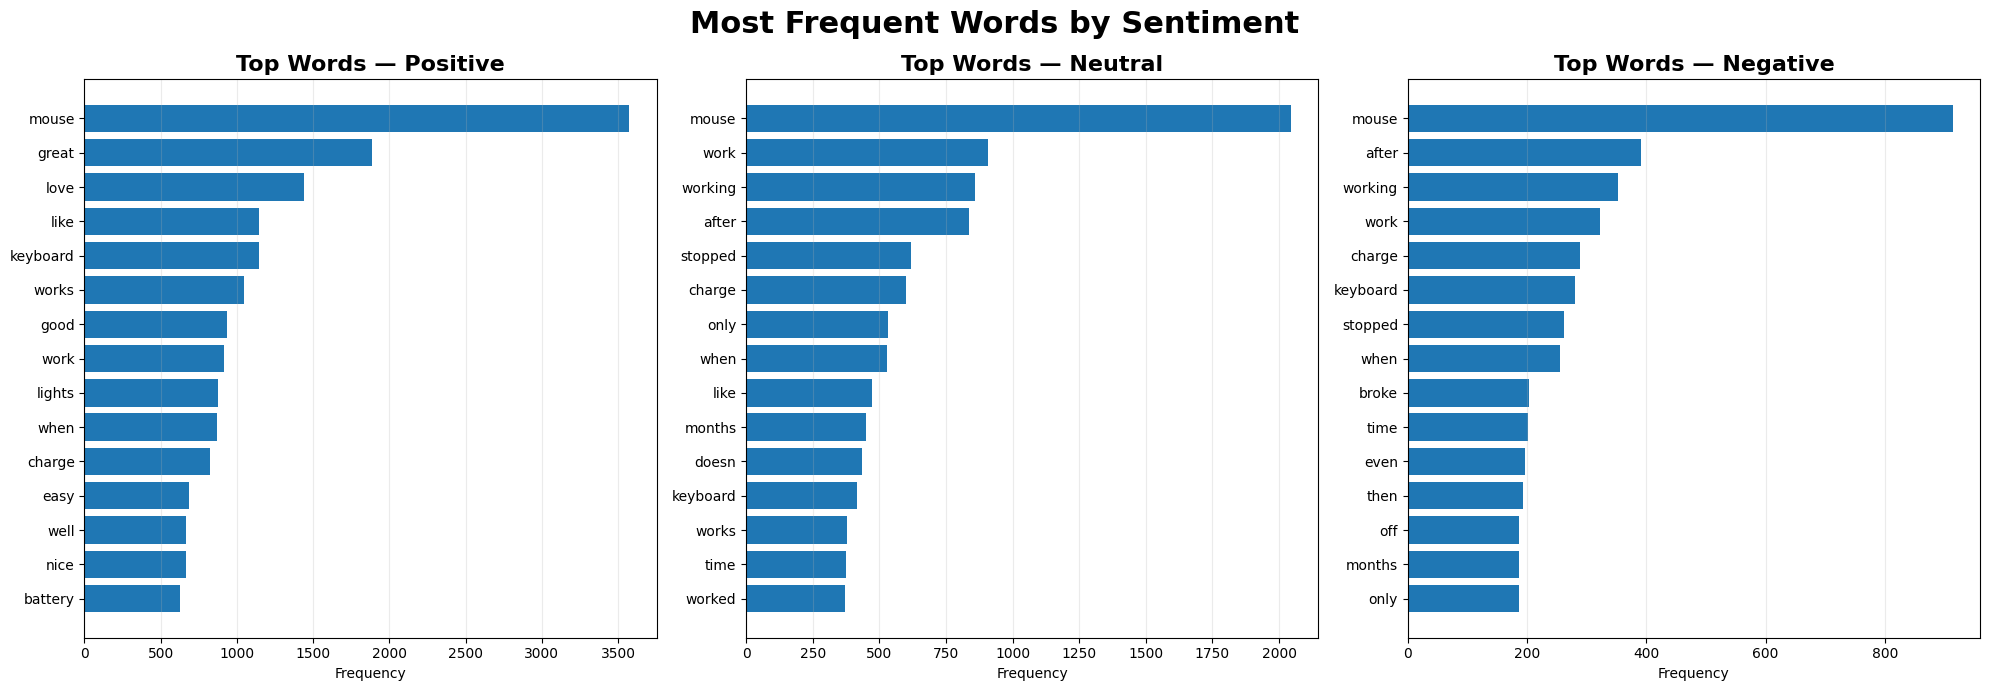

In [ ]:
# ============================================================
# STEP 5 — WORD CLOUDS & IMPORTANT WORDS
# ============================================================

!pip -q install wordcloud

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import pandas as pd
import re

# ------------------------------------------------------------
# 1. Make sure review text is clean
# ------------------------------------------------------------

df['cleaned_review'] = df['cleaned_review'].fillna('').astype(str)

# Remove empty reviews
df = df[df['cleaned_review'].str.strip() != ''].copy()

# Sentiments
sentiments = ['positive', 'neutral', 'negative']

# ------------------------------------------------------------
# 2. Stopwords
# ------------------------------------------------------------

stopwords = {
    'the', 'and', 'a', 'to', 'of', 'is', 'it', 'in', 'for',
    'this', 'that', 'was', 'with', 'on', 'my', 'i', 'but',
    'have', 'has', 'had', 'be', 'are', 'as', 'not', 'so',
    'very', 'they', 'you', 'we', 'he', 'she', 'from', 'or',
    'at', 'an', 'by', 'will', 'would', 'can', 'could',
    'one', 'all', 'more', 'just', 'get', 'got', 'been',
    'were', 'its', 'im', 'ive', 'dont', 'did', 'do',
    'does', 'didnt', 'really', 'also', 'use', 'using',
    'used', 'product', 'amazon'
}

# ------------------------------------------------------------
# 3. Function to clean words
# ------------------------------------------------------------

def get_words(text):
    text = text.lower()
    words = re.findall(r'\b[a-z]{3,}\b', text)

    words = [
        word for word in words
        if word not in stopwords
    ]

    return words


# ------------------------------------------------------------
# 4. Generate Word Clouds
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7)
)

for ax, sentiment in zip(axes, sentiments):

    text = ' '.join(
        df.loc[
            df['sentiments'] == sentiment,
            'cleaned_review'
        ]
    )

    words = get_words(text)

    word_text = ' '.join(words)

    wordcloud = WordCloud(
        width=800,
        height=500,
        background_color='white',
        max_words=100,
        collocations=False
    ).generate(word_text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')

    ax.set_title(
        f'{sentiment.capitalize()} Reviews',
        fontsize=18,
        fontweight='bold'
    )

plt.suptitle(
    'Word Clouds by Sentiment',
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. TOP 20 WORDS BY SENTIMENT
# ============================================================

top_words = {}

for sentiment in sentiments:

    text = ' '.join(
        df.loc[
            df['sentiments'] == sentiment,
            'cleaned_review'
        ]
    )

    words = get_words(text)

    counter = Counter(words)

    top_words[sentiment] = counter.most_common(20)


# ------------------------------------------------------------
# 6. Display Top Words
# ------------------------------------------------------------

for sentiment in sentiments:

    print('\n' + '=' * 60)
    print(f'TOP 20 WORDS — {sentiment.upper()} REVIEWS')
    print('=' * 60)

    for word, count in top_words[sentiment]:
        print(f'{word:<25} {count:,}')


# ============================================================
# 7. TOP 15 WORDS VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 7)
)

for ax, sentiment in zip(axes, sentiments):

    words = [
        item[0]
        for item in top_words[sentiment][:15]
    ]

    counts = [
        item[1]
        for item in top_words[sentiment][:15]
    ]

    words = words[::-1]
    counts = counts[::-1]

    ax.barh(words, counts)

    ax.set_title(
        f'Top Words — {sentiment.capitalize()}',
        fontsize=16,
        fontweight='bold'
    )

    ax.set_xlabel('Frequency')

    ax.grid(
        axis='x',
        alpha=0.25
    )

plt.suptitle(
    'Most Frequent Words by Sentiment',
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

SENTIMENT PERCENTAGE DISTRIBUTION
Positive    5,126 reviews (47.38%)
Neutral     4,437 reviews (41.01%)
Negative    1,256 reviews (11.61%)


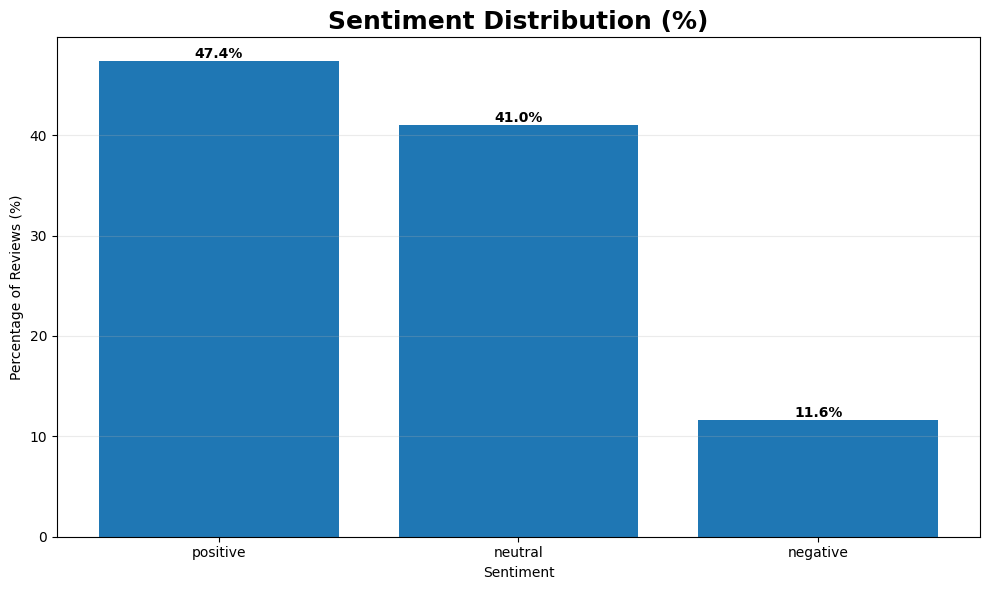


AVERAGE REVIEW SCORE BY SENTIMENT
Positive   3.33 stars
Neutral    3.18 stars
Negative   3.14 stars


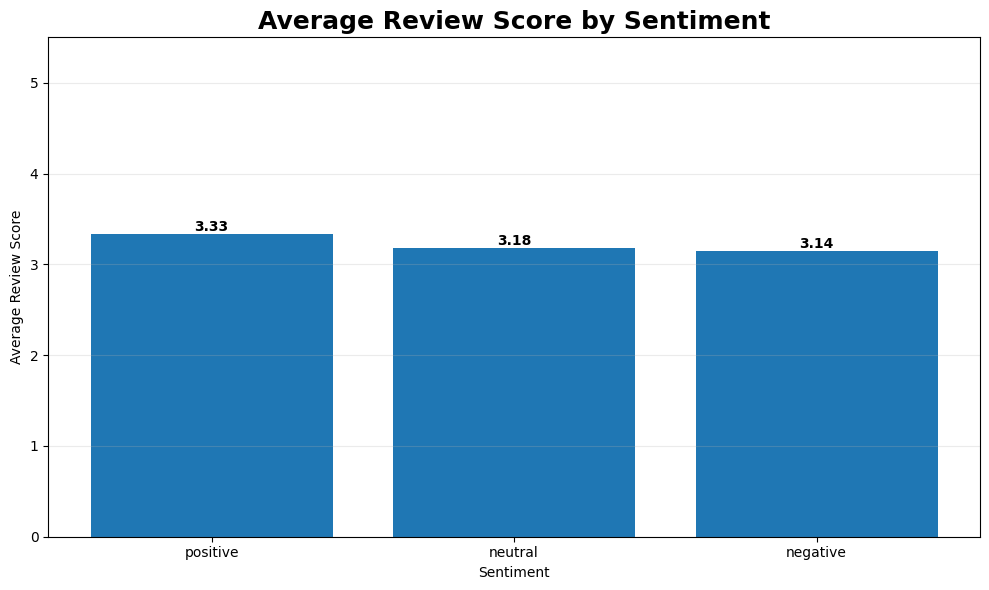


AVERAGE REVIEW LENGTH BY SENTIMENT
Positive   37.85 words
Neutral    25.00 words
Negative   44.18 words


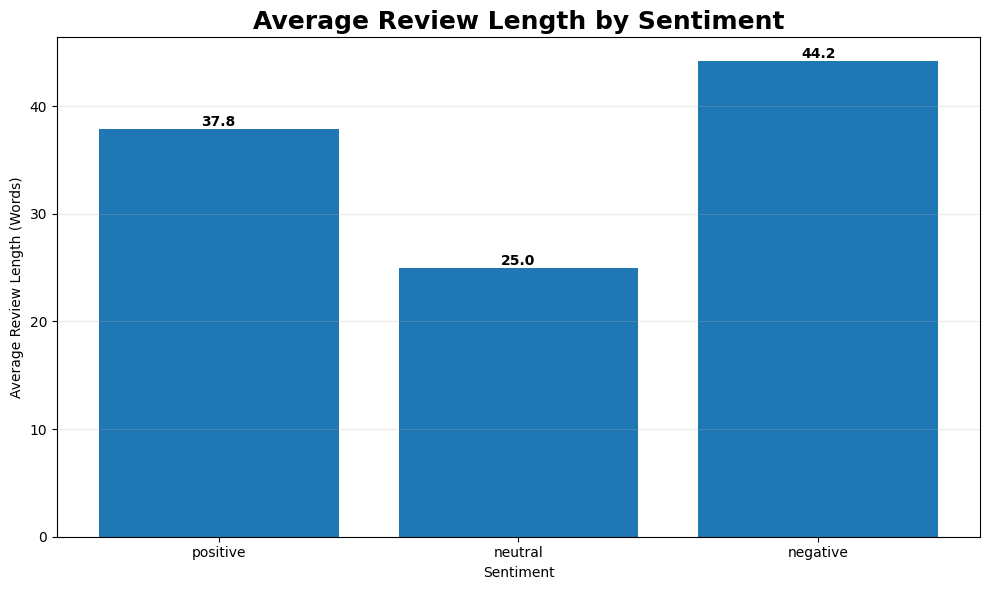


SENTIMENT VS REVIEW SCORE


sentiments,negative,neutral,positive
review_score,,,
1.0,415,1404,1465
2.0,120,465,485
3.0,99,345,389
4.0,116,383,464
5.0,506,1840,2323


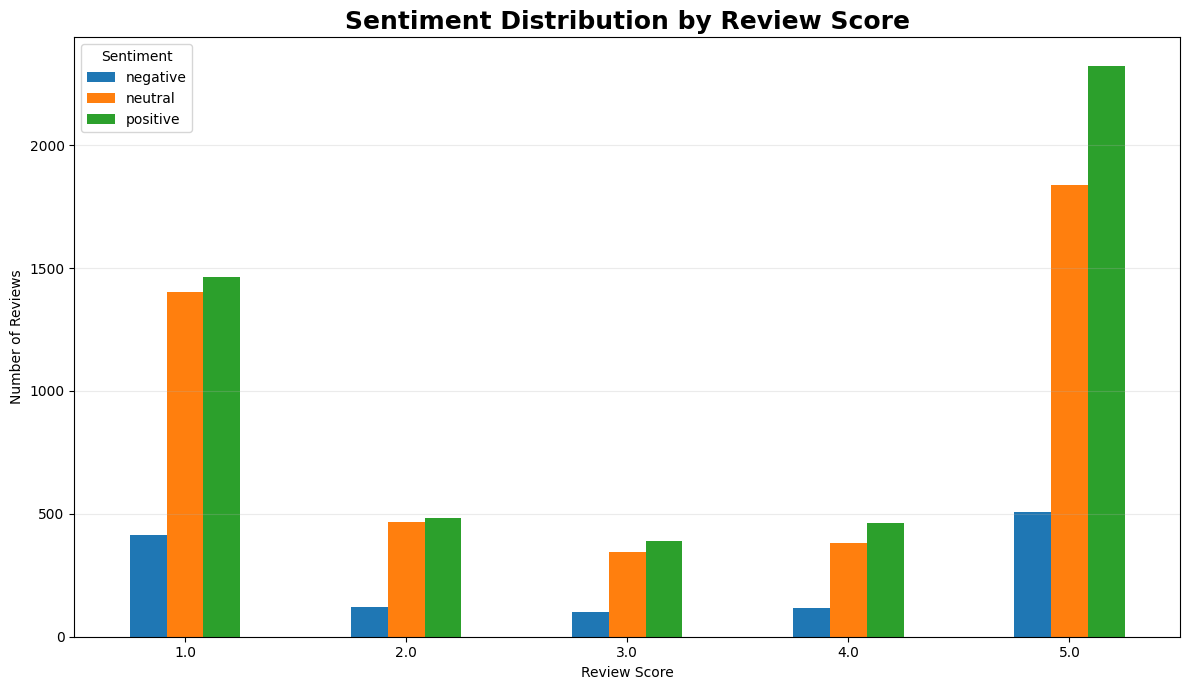



KEY SENTIMENT INSIGHTS

1. Positive sentiment has the largest share of reviews (47.38%).
2. Negative sentiment has the smallest share of reviews (11.61%).
3. Positive reviews have the highest average review score (3.33/5).
4. Negative reviews have the highest average review length (44.18 words).
5. Among 5-star reviews, Positive sentiment has the highest number of reviews.

STEP 6 COMPLETE


In [ ]:
# ============================================================
# STEP 6 — SENTIMENT TRENDS & INSIGHTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Make sure required columns have correct data types
# ------------------------------------------------------------

df['sentiments'] = df['sentiments'].astype(str).str.lower().str.strip()
df['review_score'] = pd.to_numeric(df['review_score'], errors='coerce')
df['cleaned_review_length'] = pd.to_numeric(
    df['cleaned_review_length'],
    errors='coerce'
)

# Remove rows missing required analysis values
analysis_df = df.dropna(
    subset=[
        'sentiments',
        'review_score',
        'cleaned_review_length'
    ]
).copy()

# Keep only valid sentiments
analysis_df = analysis_df[
    analysis_df['sentiments'].isin(
        ['positive', 'neutral', 'negative']
    )
].copy()

# ============================================================
# 1. SENTIMENT PERCENTAGE DISTRIBUTION
# ============================================================

sentiment_counts = (
    analysis_df['sentiments']
    .value_counts()
    .reindex(['positive', 'neutral', 'negative'])
)

sentiment_percent = (
    sentiment_counts / sentiment_counts.sum() * 100
)

print("=" * 60)
print("SENTIMENT PERCENTAGE DISTRIBUTION")
print("=" * 60)

for sentiment in sentiment_counts.index:
    print(
        f"{sentiment.capitalize():<10} "
        f"{sentiment_counts[sentiment]:>6,} reviews "
        f"({sentiment_percent[sentiment]:.2f}%)"
    )


# Visualization

plt.figure(figsize=(10, 6))

bars = plt.bar(
    sentiment_percent.index,
    sentiment_percent.values
)

plt.title(
    'Sentiment Distribution (%)',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Percentage of Reviews (%)')

plt.grid(
    axis='y',
    alpha=0.25
)

for bar, value in zip(
    bars,
    sentiment_percent.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# ============================================================
# 2. AVERAGE REVIEW SCORE BY SENTIMENT
# ============================================================

avg_score = (
    analysis_df
    .groupby('sentiments')['review_score']
    .mean()
    .reindex(['positive', 'neutral', 'negative'])
)

print("\n" + "=" * 60)
print("AVERAGE REVIEW SCORE BY SENTIMENT")
print("=" * 60)

for sentiment, score in avg_score.items():
    print(
        f"{sentiment.capitalize():<10} "
        f"{score:.2f} stars"
    )


plt.figure(figsize=(10, 6))

bars = plt.bar(
    avg_score.index,
    avg_score.values
)

plt.title(
    'Average Review Score by Sentiment',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Average Review Score')

plt.ylim(0, 5.5)

plt.grid(
    axis='y',
    alpha=0.25
)

for bar, value in zip(
    bars,
    avg_score.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# ============================================================
# 3. AVERAGE REVIEW LENGTH BY SENTIMENT
# ============================================================

avg_length = (
    analysis_df
    .groupby('sentiments')['cleaned_review_length']
    .mean()
    .reindex(['positive', 'neutral', 'negative'])
)

print("\n" + "=" * 60)
print("AVERAGE REVIEW LENGTH BY SENTIMENT")
print("=" * 60)

for sentiment, length in avg_length.items():
    print(
        f"{sentiment.capitalize():<10} "
        f"{length:.2f} words"
    )


plt.figure(figsize=(10, 6))

bars = plt.bar(
    avg_length.index,
    avg_length.values
)

plt.title(
    'Average Review Length by Sentiment',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Average Review Length (Words)')

plt.grid(
    axis='y',
    alpha=0.25
)

for bar, value in zip(
    bars,
    avg_length.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.1f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# ============================================================
# 4. SENTIMENT VS REVIEW SCORE
# ============================================================

sentiment_score = pd.crosstab(
    analysis_df['review_score'],
    analysis_df['sentiments']
).reindex(
    columns=['negative', 'neutral', 'positive'],
    fill_value=0
)

print("\n" + "=" * 60)
print("SENTIMENT VS REVIEW SCORE")
print("=" * 60)

display(sentiment_score)


# Grouped bar chart

ax = sentiment_score.plot(
    kind='bar',
    figsize=(12, 7)
)

plt.title(
    'Sentiment Distribution by Review Score',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    alpha=0.25
)

plt.legend(
    title='Sentiment'
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. KEY INSIGHTS
# ============================================================

print("\n")
print("=" * 70)
print("KEY SENTIMENT INSIGHTS")
print("=" * 70)

# Highest sentiment percentage
dominant_sentiment = sentiment_percent.idxmax()

# Lowest sentiment percentage
lowest_sentiment = sentiment_percent.idxmin()

# Highest average score
highest_score_sentiment = avg_score.idxmax()

# Longest reviews
longest_reviews_sentiment = avg_length.idxmax()

# Highest score count
highest_score_count = sentiment_score.loc[
    sentiment_score.index.max()
].idxmax()

print(
    f"\n1. {dominant_sentiment.capitalize()} sentiment "
    f"has the largest share of reviews "
    f"({sentiment_percent[dominant_sentiment]:.2f}%)."
)

print(
    f"2. {lowest_sentiment.capitalize()} sentiment "
    f"has the smallest share of reviews "
    f"({sentiment_percent[lowest_sentiment]:.2f}%)."
)

print(
    f"3. {highest_score_sentiment.capitalize()} reviews "
    f"have the highest average review score "
    f"({avg_score[highest_score_sentiment]:.2f}/5)."
)

print(
    f"4. {longest_reviews_sentiment.capitalize()} reviews "
    f"have the highest average review length "
    f"({avg_length[longest_reviews_sentiment]:.2f} words)."
)

print(
    f"5. Among 5-star reviews, "
    f"{highest_score_count.capitalize()} sentiment "
    f"has the highest number of reviews."
)

print("\n" + "=" * 70)
print("STEP 6 COMPLETE")
print("=" * 70)

FINAL CLEANED DATASET FOR DASHBOARD
Rows: 9829
Columns: 4

Missing Values:
sentiments               0
cleaned_review           0
cleaned_review_length    0
review_score             0
dtype: int64

Duplicate Rows: 0

Sentiment Distribution:
sentiments
positive    4642
neutral     4035
negative    1152
Name: count, dtype: int64

Review Score Distribution:
review_score
1.0    2956
2.0    1040
3.0     816
4.0     944
5.0    4073
Name: count, dtype: int64

EXPECTED CLEANED DATA CHECK
✓ Correct! Dashboard will use 9,829 cleaned reviews.


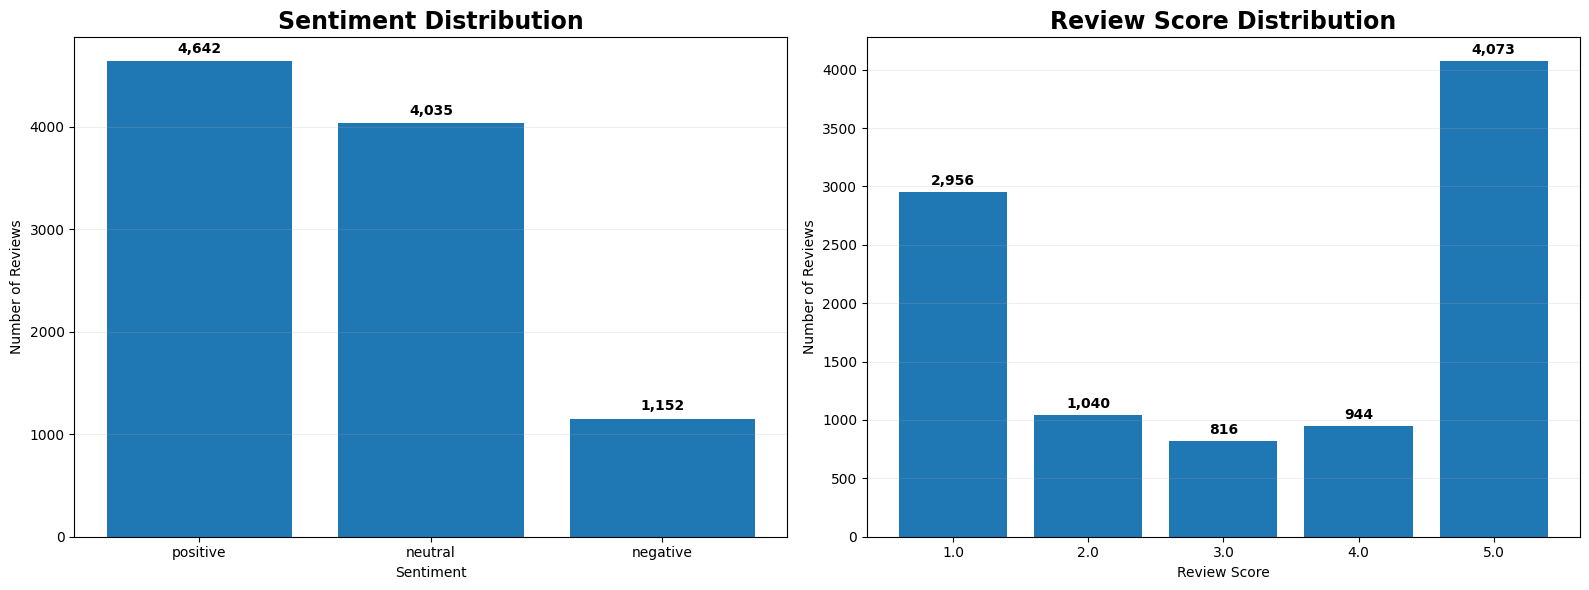

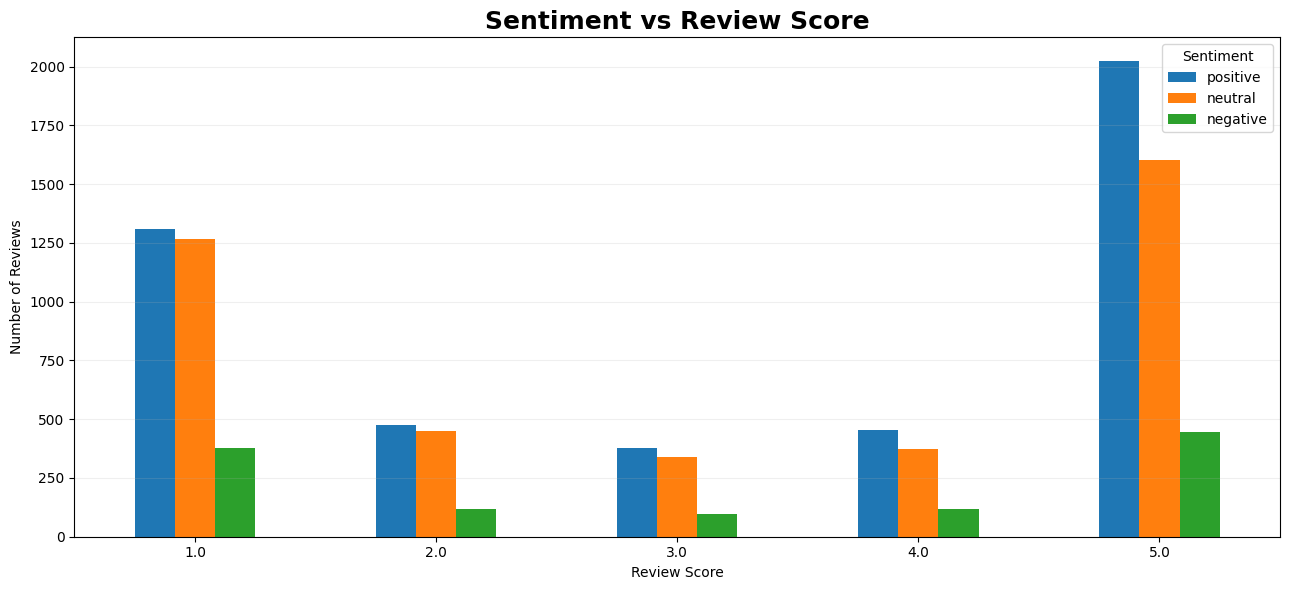

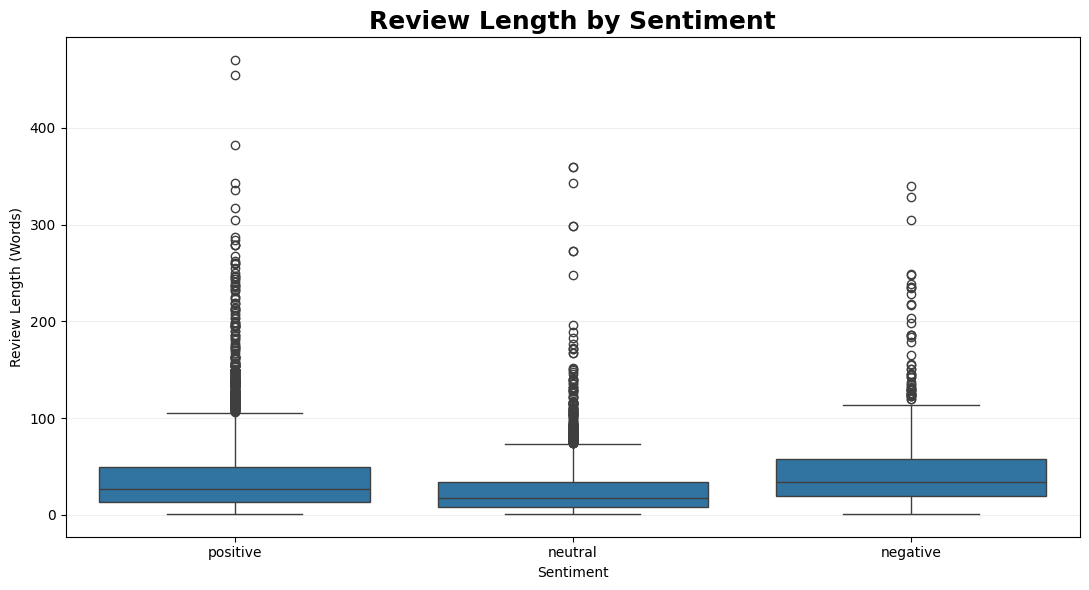

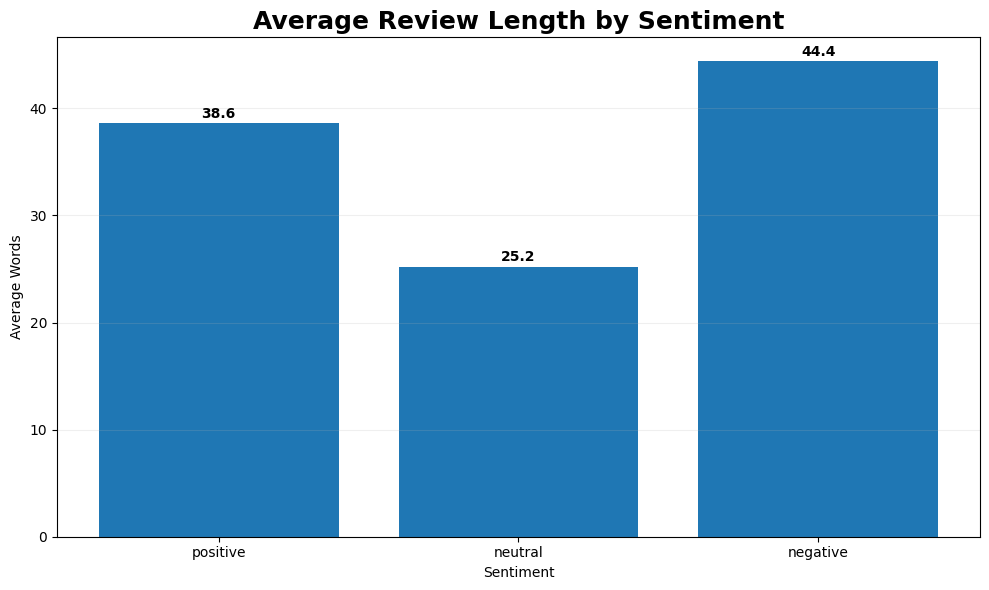


FINAL DASHBOARD DATA
Total Reviews : 9,829
Positive      : 4,642
Neutral       : 4,035
Negative      : 1,152
Average Rating: 3.22/5
Average Length: 33.79 words

Review Scores:
review_score
1.0    2956
2.0    1040
3.0     816
4.0     944
5.0    4073
Name: count, dtype: int64

Dashboard successfully generated from CLEANED DATA.


In [ ]:
# ============================================================
# STEP 7 — FINAL DASHBOARD USING CLEANED DATA ONLY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# ============================================================
# 1. CREATE CLEANED DATASET
# ============================================================

clean_df = df.copy()

# Standardize column names
clean_df.columns = clean_df.columns.str.strip()

# Standardize sentiment
clean_df['sentiments'] = (
    clean_df['sentiments']
    .astype(str)
    .str.lower()
    .str.strip()
)

# Convert numeric columns
clean_df['review_score'] = pd.to_numeric(
    clean_df['review_score'],
    errors='coerce'
)

clean_df['cleaned_review_length'] = pd.to_numeric(
    clean_df['cleaned_review_length'],
    errors='coerce'
)

# ------------------------------------------------------------
# REMOVE DUPLICATES FIRST
# ------------------------------------------------------------

clean_df = clean_df.drop_duplicates().copy()

# ------------------------------------------------------------
# REMOVE MISSING VALUES
# ------------------------------------------------------------

clean_df = clean_df.dropna(
    subset=[
        'sentiments',
        'cleaned_review',
        'cleaned_review_length',
        'review_score'
    ]
).copy()

# Keep only valid sentiments
clean_df = clean_df[
    clean_df['sentiments'].isin(
        ['positive', 'neutral', 'negative']
    )
].copy()

# ============================================================
# 2. VERIFY CLEANED DATA
# ============================================================

print("=" * 60)
print("FINAL CLEANED DATASET FOR DASHBOARD")
print("=" * 60)

print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

print("\nMissing Values:")
print(clean_df[
    [
        'sentiments',
        'cleaned_review',
        'cleaned_review_length',
        'review_score'
    ]
].isnull().sum())

print("\nDuplicate Rows:", clean_df.duplicated().sum())

print("\nSentiment Distribution:")
print(clean_df['sentiments'].value_counts())

print("\nReview Score Distribution:")
print(clean_df['review_score'].value_counts().sort_index())

# ============================================================
# 3. CHECK EXPECTED CLEANED DATA
# ============================================================

print("\n" + "=" * 60)
print("EXPECTED CLEANED DATA CHECK")
print("=" * 60)

if len(clean_df) == 9829:
    print("✓ Correct! Dashboard will use 9,829 cleaned reviews.")
else:
    print(
        f"⚠ Current cleaned rows = {len(clean_df):,}. "
        "Expected = 9,829."
    )

# ============================================================
# 4. KPI CALCULATIONS
# ============================================================

total_reviews = len(clean_df)

positive_count = (
    clean_df['sentiments'] == 'positive'
).sum()

neutral_count = (
    clean_df['sentiments'] == 'neutral'
).sum()

negative_count = (
    clean_df['sentiments'] == 'negative'
).sum()

positive_pct = positive_count / total_reviews * 100
neutral_pct = neutral_count / total_reviews * 100
negative_pct = negative_count / total_reviews * 100

avg_rating = clean_df['review_score'].mean()

avg_length = clean_df['cleaned_review_length'].mean()

# ============================================================
# 5. DASHBOARD HEADER
# ============================================================

display(HTML("""
<div style="
background:#111827;
padding:24px;
border-radius:14px;
text-align:center;
margin-bottom:18px;
font-family:Arial;
">

<h1 style="
color:white;
margin:0;
font-size:30px;
">
AMAZON REVIEW SENTIMENT ANALYSIS
</h1>

<p style="
color:#d1d5db;
margin:8px 0 0 0;
font-size:15px;
">
Cleaned Dataset • Sentiment • Ratings • Review Behavior
</p>

</div>
"""))

# ============================================================
# 6. KPI CARDS — CLEANED DATA
# ============================================================

display(HTML(f"""

<div style="
display:grid;
grid-template-columns:repeat(5,1fr);
gap:10px;
font-family:Arial;
margin-bottom:20px;
">

<div style="
background:#111827;
color:white;
padding:16px;
border-radius:12px;
text-align:center;
">
<div style="font-size:13px;color:#d1d5db;">
TOTAL REVIEWS
</div>

<div style="
font-size:27px;
font-weight:bold;
margin-top:5px;
">
{total_reviews:,}
</div>
</div>


<div style="
background:#166534;
color:white;
padding:16px;
border-radius:12px;
text-align:center;
">
<div style="font-size:13px;">
POSITIVE
</div>

<div style="
font-size:27px;
font-weight:bold;
margin-top:5px;
">
{positive_count:,}
</div>

<div style="font-size:13px;">
{positive_pct:.1f}%
</div>
</div>


<div style="
background:#4b5563;
color:white;
padding:16px;
border-radius:12px;
text-align:center;
">
<div style="font-size:13px;">
NEUTRAL
</div>

<div style="
font-size:27px;
font-weight:bold;
margin-top:5px;
">
{neutral_count:,}
</div>

<div style="font-size:13px;">
{neutral_pct:.1f}%
</div>
</div>


<div style="
background:#991b1b;
color:white;
padding:16px;
border-radius:12px;
text-align:center;
">
<div style="font-size:13px;">
NEGATIVE
</div>

<div style="
font-size:27px;
font-weight:bold;
margin-top:5px;
">
{negative_count:,}
</div>

<div style="font-size:13px;">
{negative_pct:.1f}%
</div>
</div>


<div style="
background:#92400e;
color:white;
padding:16px;
border-radius:12px;
text-align:center;
">
<div style="font-size:13px;">
AVG RATING
</div>

<div style="
font-size:27px;
font-weight:bold;
margin-top:5px;
">
{avg_rating:.2f}/5
</div>

<div style="font-size:13px;">
Avg Length: {avg_length:.1f} words
</div>
</div>

</div>

"""))

# ============================================================
# 7. SENTIMENT DISTRIBUTION + REVIEW SCORE
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

# ------------------------------------------------------------
# SENTIMENT
# ------------------------------------------------------------

sentiment_order = [
    'positive',
    'neutral',
    'negative'
]

sentiment_counts = (
    clean_df['sentiments']
    .value_counts()
    .reindex(sentiment_order)
)

bars = axes[0].bar(
    sentiment_counts.index,
    sentiment_counts.values
)

axes[0].set_title(
    'Sentiment Distribution',
    fontsize=17,
    fontweight='bold'
)

axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Reviews')

axes[0].grid(
    axis='y',
    alpha=0.2
)

for bar, value in zip(
    bars,
    sentiment_counts.values
):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        value + 80,
        f'{value:,}',
        ha='center',
        fontweight='bold'
    )

# ------------------------------------------------------------
# REVIEW SCORE
# ------------------------------------------------------------

score_counts = (
    clean_df['review_score']
    .value_counts()
    .sort_index()
)

bars = axes[1].bar(
    score_counts.index.astype(str),
    score_counts.values
)

axes[1].set_title(
    'Review Score Distribution',
    fontsize=17,
    fontweight='bold'
)

axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Number of Reviews')

axes[1].grid(
    axis='y',
    alpha=0.2
)

for bar, value in zip(
    bars,
    score_counts.values
):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        value + 60,
        f'{value:,}',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# ============================================================
# 8. SENTIMENT VS REVIEW SCORE
# ============================================================

sentiment_score = pd.crosstab(
    clean_df['review_score'],
    clean_df['sentiments']
)

sentiment_score = sentiment_score.reindex(
    columns=sentiment_order,
    fill_value=0
)

ax = sentiment_score.plot(
    kind='bar',
    figsize=(13,6)
)

plt.title(
    'Sentiment vs Review Score',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    alpha=0.2
)

plt.legend(
    title='Sentiment'
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. REVIEW LENGTH BY SENTIMENT
# ============================================================

plt.figure(figsize=(11,6))

sns.boxplot(
    data=clean_df,
    x='sentiments',
    y='cleaned_review_length',
    order=sentiment_order
)

plt.title(
    'Review Length by Sentiment',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Review Length (Words)')

plt.grid(
    axis='y',
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. AVERAGE REVIEW LENGTH
# ============================================================

avg_length_by_sentiment = (
    clean_df
    .groupby('sentiments')['cleaned_review_length']
    .mean()
    .reindex(sentiment_order)
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    avg_length_by_sentiment.index,
    avg_length_by_sentiment.values
)

plt.title(
    'Average Review Length by Sentiment',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Average Words')

plt.grid(
    axis='y',
    alpha=0.2
)

for bar, value in zip(
    bars,
    avg_length_by_sentiment.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f'{value:.1f}',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# ============================================================
# 11. FINAL DASHBOARD VALIDATION
# ============================================================

print("\n" + "=" * 65)
print("FINAL DASHBOARD DATA")
print("=" * 65)

print(f"Total Reviews : {total_reviews:,}")
print(f"Positive      : {positive_count:,}")
print(f"Neutral       : {neutral_count:,}")
print(f"Negative      : {negative_count:,}")
print(f"Average Rating: {avg_rating:.2f}/5")
print(f"Average Length: {avg_length:.2f} words")

print("\nReview Scores:")
print(score_counts)

print("\nDashboard successfully generated from CLEANED DATA.")

# Business Recommendations

Based on the sentiment analysis, emotion analysis, review scores, and frequently used words, the following business recommendations can be made:

### 1. Improve Product Reliability and Durability
Negative reviews frequently contain words such as **"broke", "stopped", "working", and "months"**, indicating concerns about product reliability and durability. Businesses should improve quality testing and long-term product performance.

### 2. Focus on Mouse and Keyboard Quality
The word **"mouse"** and other product-related terms such as **"keyboard"** and **"working"** appear frequently across customer reviews. Businesses should continuously monitor the performance and quality of these products.

### 3. Improve Battery and Charging Performance
Words such as **"battery"** and **"charge"** frequently appear in customer feedback. Improving battery life, charging speed, and charging reliability can help improve customer satisfaction.

### 4. Maintain Popular Product Features
Positive reviews frequently include words such as **"great", "love", "good", "easy", "nice", "lights", and "colors"**. These features should be maintained and further improved because they are associated with positive customer experiences.

### 5. Address Customer Frustration
The emotion analysis shows notable levels of **anger and sadness**, particularly within negative and neutral reviews. Businesses should investigate the causes of these emotions and prioritize the underlying product issues.

### 6. Use Customer Feedback for Product Development
Sentiment, emotion, review score, and word-frequency analysis can provide valuable customer insights. Businesses should regularly use customer reviews to identify product problems, understand customer preferences, and guide product development decisions.

## Overall Business Conclusion

The analysis indicates that customers appreciate several product features, but negative feedback highlights important concerns related to product reliability, performance, battery, and charging. Businesses can improve customer satisfaction by maintaining popular features while addressing recurring product issues identified through customer reviews.